In [3]:
import pandas as pd
import numpy as np
import requests
import zipfile
import io

url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall()

ratings = pd.read_csv('ml-latest-small/ratings.csv')
movies = pd.read_csv('ml-latest-small/movies.csv')

df = pd.merge(ratings, movies, on='movieId')

df_high_rated = df[df['rating'] >= 4.0]

print(f"Розмір вихідної таблиці: {df.shape}")
print(f"Розмір після фільтрації (rating >= 4): {df_high_rated.shape}")
print(f"Унікальних користувачів: {df_high_rated['userId'].nunique()}")
print(f"Унікальних фільмів: {df_high_rated['title'].nunique()}")

Розмір вихідної таблиці: (100836, 6)
Розмір після фільтрації (rating >= 4): (48580, 6)
Унікальних користувачів: 609
Унікальних фільмів: 6297


In [14]:
basket = (df_high_rated
          .groupby(['userId', 'title'])['rating']
          .count().unstack().reset_index().fillna(0)
          .set_index('userId'))

def encode_units(x):
    return x >= 1

basket_sets = basket.map(encode_units).astype(bool)

print("\nФрагмент матриці транзакцій (перші 5 користувачів):")
display(basket_sets.iloc[:5, :10])


Фрагмент матриці транзакцій (перші 5 користувачів):


title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",(500) Days of Summer (2009),*batteries not included (1987),...And Justice for All (1979),00 Schneider - Jagd auf Nihil Baxter (1994),1-900 (06) (1994)
userId,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False


In [11]:
from mlxtend.frequent_patterns import apriori, association_rules

supports = [0.05, 0.07, 0.1]
for s in supports:
    frequent_itemsets_temp = apriori(basket_sets, min_support=s, use_colnames=True)
    print(f"Кількість наборів при min_support={s}: {len(frequent_itemsets_temp)}")

frequent_itemsets = apriori(basket_sets, min_support=0.07, use_colnames=True)

print("\nТоп-10 частих наборів фільмів:")
display(frequent_itemsets.sort_values('support', ascending=False).head(10))

Кількість наборів при min_support=0.05: 33189
Кількість наборів при min_support=0.07: 5073
Кількість наборів при min_support=0.1: 863

Топ-10 частих наборів фільмів:


,support,itemsets
168,0.449918,"(Shawshank Redemption, The (1994))"
73,0.408867,(Forrest Gump (1994))
153,0.400657,(Pulp Fiction (1994))
173,0.369458,"(Silence of the Lambs, The (1991))"
128,0.364532,"(Matrix, The (1999))"
186,0.330049,(Star Wars: Episode IV - A New Hope (1977))
69,0.293924,(Fight Club (1999))
164,0.287356,(Schindler's List (1993))
187,0.275862,(Star Wars: Episode V - The Empire Strikes Bac...
893,0.275862,"(Forrest Gump (1994), Shawshank Redemption, Th..."


Топ-10 асоціативних правил за показником Lift:


,antecedents,consequents,support,confidence,lift
17919,"(Lord of the Rings: The Return of the King, Th...","(Lord of the Rings: The Two Towers, The (2002)...",0.07225,0.785714,8.394737
17952,"(Lord of the Rings: The Two Towers, The (2002)...","(Lord of the Rings: The Return of the King, Th...",0.07225,0.771930,8.394737
17928,"(Lord of the Rings: The Two Towers, The (2002)...","(Lord of the Rings: The Return of the King, Th...",0.07225,0.880000,8.373750
17949,"(Lord of the Rings: The Return of the King, Th...","(Lord of the Rings: The Two Towers, The (2002)...",0.07225,0.687500,8.373750
17936,"(Lord of the Rings: The Return of the King, Th...","(Lord of the Rings: The Two Towers, The (2002)...",0.07225,0.846154,8.179487
17942,"(Lord of the Rings: The Two Towers, The (2002)...","(Lord of the Rings: The Return of the King, Th...",0.07225,0.698413,8.179487
17938,"(Lord of the Rings: The Return of the King, Th...","(Lord of the Rings: The Two Towers, The (2002)...",0.07225,0.733333,8.120000
17940,"(Lord of the Rings: The Two Towers, The (2002)...","(Lord of the Rings: The Return of the King, Th...",0.07225,0.800000,8.120000
17951,"(Lord of the Rings: The Two Towers, The (2002)...","(Lord of the Rings: The Return of the King, Th...",0.07225,0.647059,8.042017
17922,"(Lord of the Rings: The Return of the King, Th...","(Lord of the Rings: The Two Towers, The (2002)...",0.07225,0.897959,8.042017


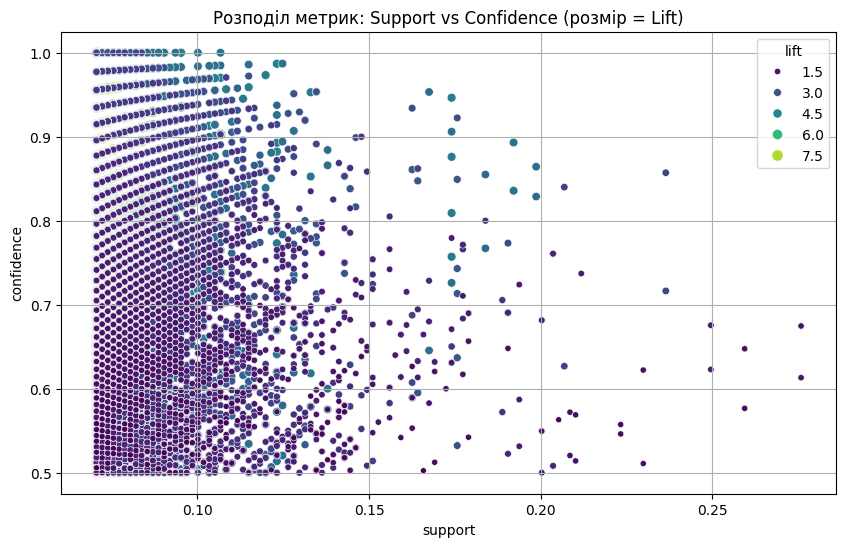

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

rules = rules.sort_values('lift', ascending=False)

print("Топ-10 асоціативних правил за показником Lift:")
display(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

plt.figure(figsize=(10, 6))
sns.scatterplot(data=rules, x="support", y="confidence", size="lift", hue="lift", palette="viridis")
plt.title("Розподіл метрик: Support vs Confidence (розмір = Lift)")
plt.grid(True)
plt.show()